In [252]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler, StandardScaler

FEATURE_COLS = ['request_rate']
TARGET_COL = 'replica_count'
DELTA_RPS_WINDOW = 5
EPOCHS = 100
BATCH_SIZE = 64
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
SEQ_LENGTH = 20

df = pd.read_csv('../dataset/training_dataset.csv', index_col=0)
df = df.sort_index()

# Curățare
df = df[df['replica_count'] > 0]
df = df[df['replica_count'] < 9]
df = df[~((df['cpu_usage'] == 0) &
          (df['request_rate'] == 0) &
          (df['replica_count'] == 0))]
df['replica_count'] = df['replica_count'].replace(0, np.nan).ffill().bfill()
df = df.dropna(subset=['request_rate', 'replica_count'])
df = df.sort_index().reset_index()

if 'session_id' not in df.columns:
    df['session_id'] = '0'

# Compute delta_rps per session so slope doesn't bleed across session boundaries
feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

feature_scaler.fit(df[['request_rate']])
target_scaler.fit(df[[TARGET_COL]])

scaled_features = feature_scaler.transform(df[['request_rate']])  # shape (n, 1)
scaled_target   = target_scaler.transform(df[[TARGET_COL]]).ravel()

df['_scaled_idx'] = range(len(df))

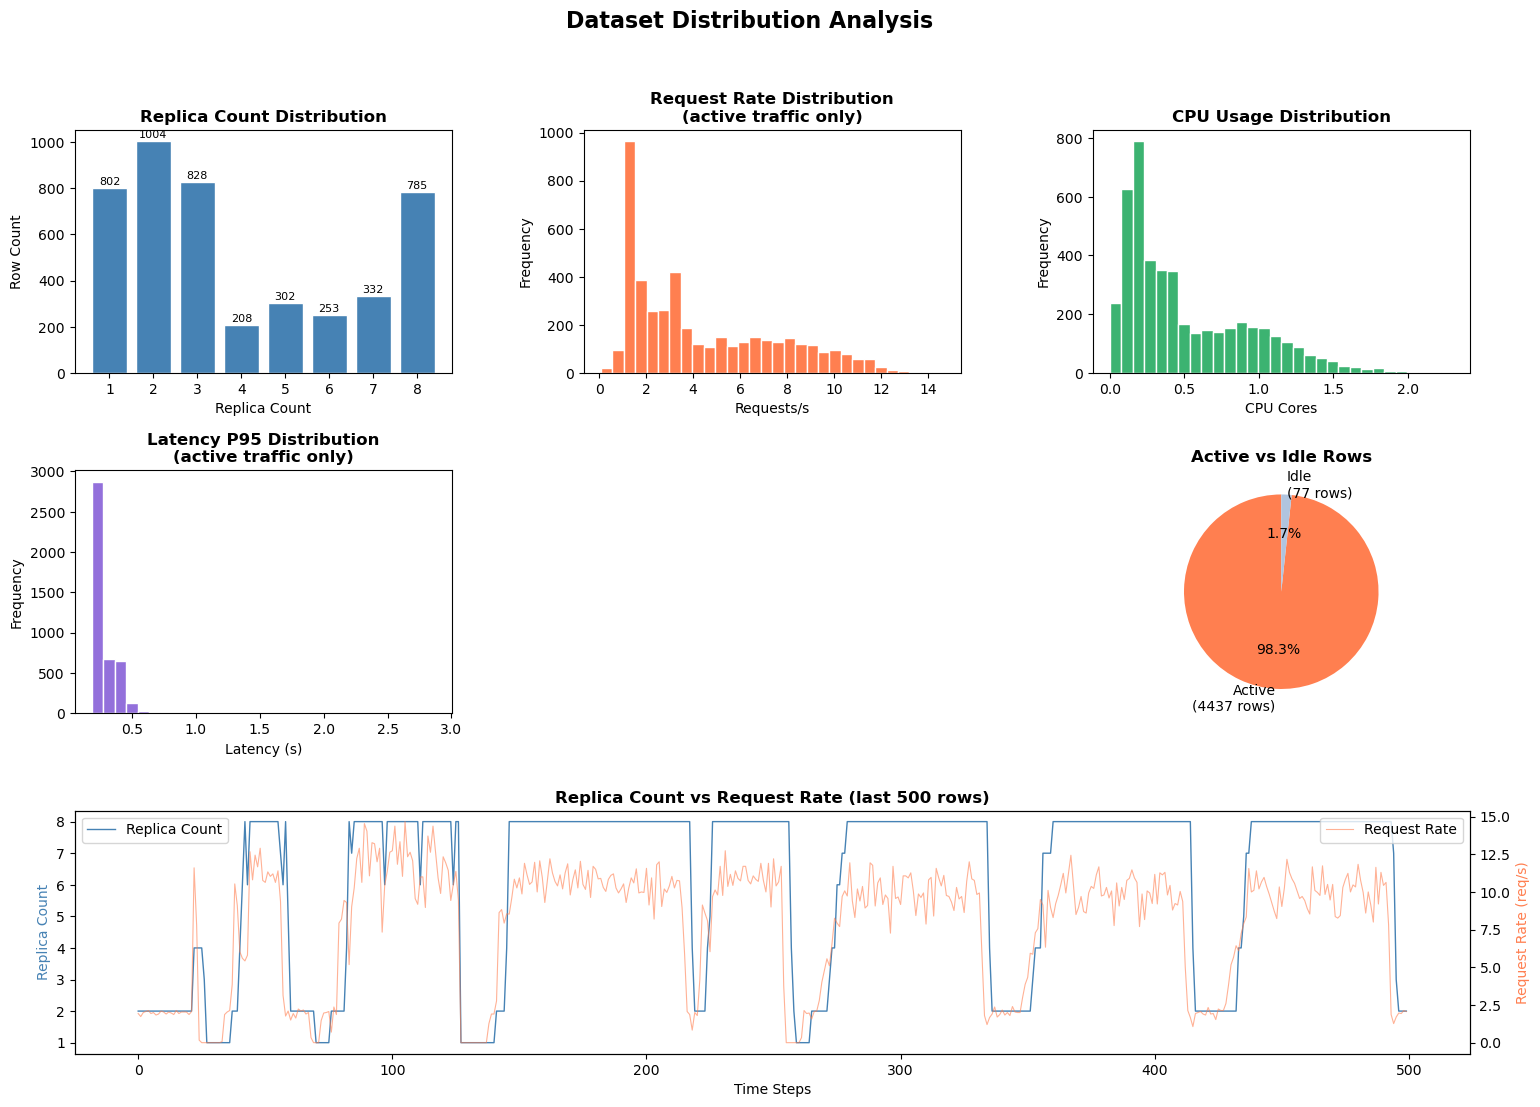


Plot saved to dataset_distribution.png


In [253]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Dataset Distribution Analysis', fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. replica count distribution
ax1 = fig.add_subplot(gs[0, 0])
replica_counts = df['replica_count'].value_counts().sort_index()
bars = ax1.bar(replica_counts.index, replica_counts.values, color='steelblue', edgecolor='white')
ax1.set_title('Replica Count Distribution', fontweight='bold')
ax1.set_xlabel('Replica Count')
ax1.set_ylabel('Row Count')
for bar, val in zip(bars, replica_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val}', ha='center', va='bottom', fontsize=8)

# 2. request rate distribution
ax2 = fig.add_subplot(gs[0, 1])
active = df[df['request_rate'] > 0]['request_rate']
ax2.hist(active, bins=30, color='coral', edgecolor='white')
ax2.set_title('Request Rate Distribution\n(active traffic only)', fontweight='bold')
ax2.set_xlabel('Requests/s')
ax2.set_ylabel('Frequency')

# 3. cpu usage distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['cpu_usage'], bins=30, color='mediumseagreen', edgecolor='white')
ax3.set_title('CPU Usage Distribution', fontweight='bold')
ax3.set_xlabel('CPU Cores')
ax3.set_ylabel('Frequency')

# 4. latency p95 distribution (active traffic only)
ax4 = fig.add_subplot(gs[1, 0])
active_lat = df[df['latency_p95'] > 0]['latency_p95']
ax4.hist(active_lat, bins=30, color='mediumpurple', edgecolor='white')
ax4.set_title('Latency P95 Distribution\n(active traffic only)', fontweight='bold')
ax4.set_xlabel('Latency (s)')
ax4.set_ylabel('Frequency')



# 6. idle vs active pie
ax6 = fig.add_subplot(gs[1, 2])
idle = len(df[df['request_rate'] == 0])
active_rows = len(df[df['request_rate'] > 0])
ax6.pie([active_rows, idle],
        labels=[f'Active\n({active_rows} rows)', f'Idle\n({idle} rows)'],
        colors=['coral', 'lightsteelblue'],
        autopct='%1.1f%%', startangle=90)
ax6.set_title('Active vs Idle Rows', fontweight='bold')

# 7. scaling events — replica count over time (sample of 500 rows)
ax7 = fig.add_subplot(gs[2, :])
sample = df.tail(500) if len(df) > 500 else df
ax7.plot(range(len(sample)), sample['replica_count'],
         color='steelblue', linewidth=1, label='Replica Count')
ax7_twin = ax7.twinx()
ax7_twin.plot(range(len(sample)), sample['request_rate'],
              color='coral', linewidth=0.8, alpha=0.6, label='Request Rate')
ax7.set_title('Replica Count vs Request Rate (last 500 rows)', fontweight='bold')
ax7.set_xlabel('Time Steps')
ax7.set_ylabel('Replica Count', color='steelblue')
ax7_twin.set_ylabel('Request Rate (req/s)', color='coral')
ax7.legend(loc='upper left')
ax7_twin.legend(loc='upper right')

plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to dataset_distribution.png")

In [254]:
HORIZON = 3

unique_sessions = df['session_id'].unique()

print(f"\nSesiuni alocate pentru Train: {unique_sessions}")

def create_sequences_from_sessions(df, scaled_features, scaled_target, sessions, seq_length, horizon=HORIZON):
    X, y = [], []
    for session_id in sessions:
        session_mask = df['session_id'] == session_id
        session_indices = df[session_mask]['_scaled_idx'].values
        feat_data = scaled_features[session_indices]
        tgt_data  = scaled_target[session_indices]

        if len(feat_data) < seq_length + horizon + 1:
            print(f"Sesiunea {session_id} prea scurtă ({len(feat_data)} rânduri), ignorată.")
            continue

        for i in range(len(feat_data) - seq_length - horizon):
            X.append(feat_data[i:i + seq_length])
            y.append(tgt_data[i + seq_length + horizon])

    X, y = np.array(X), np.array(y)

    # Oversample sequences where target replica count >= 6
    # Inverse transform to get actual replica counts for filtering
    y_unscaled = target_scaler.inverse_transform(y.reshape(-1,1)).ravel()
    high_load_mask = y_unscaled >= 6
    
    repeat_factor = 4  # repeat high-load sequences 4x
    X_high = np.repeat(X[high_load_mask], repeat_factor, axis=0)
    y_high = np.repeat(y[high_load_mask], repeat_factor, axis=0)
    
    X = np.concatenate([X, X_high], axis=0)
    y = np.concatenate([y, y_high], axis=0)
    
    print(f"After oversampling: {len(X)} sequences ({high_load_mask.sum()} high-load × {repeat_factor} + {(~high_load_mask).sum()} normal)")
    return X, y

X_train, y_train = create_sequences_from_sessions(
    df, scaled_features, scaled_target, unique_sessions, SEQ_LENGTH
)
print(f"\nDistribuție secvențe:")
print(f"Train: {len(X_train)} secvențe")


Sesiuni alocate pentru Train: <ArrowStringArray>
[                           '0',                            '1',
                            '2',                            '3',
 'transition_test_0_1778333484', 'transition_test_0_1778334664',
 'transition_test_0_1778340098', 'transition_test_0_1778343802']
Length: 8, dtype: str
After oversampling: 8742 sequences (1103 high-load × 4 + 3227 normal)

Distribuție secvențe:
Train: 8742 secvențe


In [255]:
class K8sDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self): return len(self.X)

    def __getitem__(self, idx): return self.X[idx], self.y[idx]


train_loader = DataLoader(K8sDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)  



In [256]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1,
                            batch_first=True, dropout=0)
        self.fc = nn.Linear(hidden_size + 1, 1)  # +1 for skip connection

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]           # final LSTM state
        current_rr  = x[:, -1, :]            # skip connection: raw current RPS
        combined    = torch.cat([last_hidden, current_rr], dim=1)
        return self.fc(combined)


In [257]:
def weighted_mse_loss(pred, target, target_scaler):
    # Unscale to get actual replica counts for weighting
    # Higher replica counts get higher weight
    target_unscaled = target * (target_scaler.data_max_[0] - target_scaler.data_min_[0]) + target_scaler.data_min_[0]
    weights = torch.clamp(target_unscaled, min=1.0) / 4.0  # scale weights around mean
    return (weights * (pred - target) ** 2).mean()

In [258]:
model = LSTMModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0008)
loss_fn = nn.MSELoss()

MODEL_SAVE_PATH = "best_lstm_model.pt"

print("Epoch   | Train Loss | RMSE    | MAE     | R²")
print("-" * 47)

best_train_loss = float('inf')
best_epoch = 0

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    preds, trues = [], []

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * x.size(0)
        preds.append(pred.detach().cpu().numpy())
        trues.append(y.detach().cpu().numpy())

    train_loss = total_train_loss / len(train_loader.dataset)

    preds = np.concatenate(preds).ravel()
    trues = np.concatenate(trues).ravel()

    pred_unscaled = target_scaler.inverse_transform(preds.reshape(-1, 1)).ravel()
    true_unscaled = target_scaler.inverse_transform(trues.reshape(-1, 1)).ravel()

    pred_final = np.round(np.clip(pred_unscaled, 1, None))  # min 1 replica, not 0

    rmse = np.sqrt(mean_squared_error(true_unscaled, pred_final))
    mae = mean_absolute_error(true_unscaled, pred_final)
    r2 = r2_score(true_unscaled, pred_final)

    print(f"{epoch + 1:2d}/{EPOCHS}   {train_loss:.5f}    {rmse:.4f}   {mae:.4f}   {r2:.4f}")

    if train_loss < best_train_loss:
        best_train_loss = train_loss
        best_epoch = epoch + 1  # fix: assign before saving
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': best_train_loss,
            'r2': r2,
            'feature_scaler': feature_scaler,
            'target_scaler': target_scaler,
        }, MODEL_SAVE_PATH)

print(f"\nFinalizat! Cel mai bun model a fost la epoca {best_epoch} cu Train Loss: {best_train_loss:.6f}")

Epoch   | Train Loss | RMSE    | MAE     | R²
-----------------------------------------------
 1/100   0.13199    2.5650   2.0750   0.0102
 2/100   0.04429    1.5067   1.1541   0.6585
 3/100   0.02304    1.0866   0.7191   0.8224
 4/100   0.01952    1.0111   0.6327   0.8462
 5/100   0.01816    0.9830   0.6042   0.8546
 6/100   0.01706    0.9596   0.5800   0.8615
 7/100   0.01682    0.9461   0.5682   0.8653
 8/100   0.01579    0.9251   0.5475   0.8712
 9/100   0.01501    0.9085   0.5255   0.8758
10/100   0.01447    0.8946   0.5136   0.8796
11/100   0.01417    0.8777   0.4955   0.8841
12/100   0.01360    0.8652   0.4832   0.8874
13/100   0.01328    0.8578   0.4765   0.8893
14/100   0.01305    0.8434   0.4609   0.8930
15/100   0.01260    0.8385   0.4656   0.8942
16/100   0.01252    0.8362   0.4628   0.8948
17/100   0.01222    0.8298   0.4589   0.8964
18/100   0.01211    0.8240   0.4541   0.8978
19/100   0.01178    0.8112   0.4404   0.9010
20/100   0.01157    0.8064   0.4391   0.9022
21/100

*Sample test for lstm prediction*

In [259]:
import numpy as np
import torch

TEST_SEQ_LENGTH = 10

# Take last 10 values from each 20-step window
eval_windows_20 = [
    [2.0667, 1.8301, 2.3018, 2.0333, 2.3333, 1.8333, 1.8, 1.7, 2.2667, 2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9],
    [1.8301, 2.3018, 2.0333, 2.3333, 1.8333, 1.8, 1.7, 2.2667, 2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667],
    [2.3018, 2.0333, 2.3333, 1.8333, 1.8, 1.7, 2.2667, 2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333],
    [2.0333, 2.3333, 1.8333, 1.8, 1.7, 2.2667, 2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333, 8.9667],
    [2.3333, 1.8333, 1.8, 1.7, 2.2667, 2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333, 8.9667, 10.1746],
    [1.8333, 1.8, 1.7, 2.2667, 2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333, 8.9667, 10.1746, 8.1333],
    [1.8, 1.7, 2.2667, 2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333, 8.9667, 10.1746, 8.1333, 9.7333],
    [1.7, 2.2667, 2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333, 8.9667, 10.1746, 8.1333, 9.7333, 9.8895],
    [2.2667, 2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333, 8.9667, 10.1746, 8.1333, 9.7333, 9.8895, 9.3667],
    [2.0, 1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333, 8.9667, 10.1746, 8.1333, 9.7333, 9.8895, 9.3667, 9.4667],
    [1.4333, 2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333, 8.9667, 10.1746, 8.1333, 9.7333, 9.8895, 9.3667, 9.4667, 11.3],
    [2.4, 2.1333, 1.7, 1.7, 2.1667, 4.6, 4.7, 6.1333, 6.9, 7.7667, 10.5333, 8.9667, 10.1746, 8.1333, 9.7333, 9.8895, 9.3667, 9.4667, 11.3, 9.9333],
]

eval_windows = [w[-TEST_SEQ_LENGTH:] for w in eval_windows_20]

checkpoint = torch.load('best_lstm_model.pt', map_location='cpu', weights_only=False)
print(f"Saved at epoch: {checkpoint['epoch']}")
print(f"Train loss: {checkpoint['train_loss']:.6f}")
print(f"R2: {checkpoint['r2']:.4f}")
print()

saved_model = LSTMModel().to('cpu')
saved_model.load_state_dict(checkpoint['model_state_dict'])
saved_model.eval()

feature_scaler = checkpoint['feature_scaler']
target_scaler  = checkpoint['target_scaler']

print(f"{'Window ending RR':>16} | {'Raw output':>10} | {'Unscaled':>10} | {'Predicted':>10}")
print("-" * 56)

for window in eval_windows:
    arr = np.array(window).reshape(-1, 1)
    scaled = feature_scaler.transform(arr).reshape(1, TEST_SEQ_LENGTH, 1).astype(np.float32)

    with torch.no_grad():
        raw = saved_model(torch.tensor(scaled)).numpy()[0][0]

    unscaled = target_scaler.inverse_transform([[raw]])[0][0]
    predicted = int(round(np.clip(unscaled, 1, None)))

    print(f"{window[-1]:>16.4f} | {raw:>10.4f} | {unscaled:>10.4f} | {predicted:>10}")

Saved at epoch: 99
Train loss: 0.007699
R2: 0.9361

Window ending RR | Raw output |   Unscaled |  Predicted
--------------------------------------------------------
          6.9000 |     0.8717 |     7.1021 |          7
          7.7667 |     0.9118 |     7.3829 |          7
         10.5333 |     0.9294 |     7.5058 |          8
          8.9667 |     0.9520 |     7.6638 |          8
         10.1746 |     0.9883 |     7.9184 |          8
          8.1333 |     0.9732 |     7.8127 |          8
          9.7333 |     0.9529 |     7.6701 |          8
          9.8895 |     0.9629 |     7.7401 |          8
          9.3667 |     0.9641 |     7.7487 |          8
          9.4667 |     0.9645 |     7.7517 |          8
         11.3000 |     0.9658 |     7.7605 |          8
          9.9333 |     0.9692 |     7.7845 |          8


/Users/fabianiancu/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/fabianiancu/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/fabianiancu/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/fabianiancu/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/fabianiancu/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted w